<h1 align="center">Communities and Crime Dataset</h1>
<h3 align="center">Branislav Trstenský</h3>

> Dataset: UCI Machine Learning Repository (ID: 183)\
> Redmond, M. (2002). Communities and Crime.\
> <https://doi.org/10.24432/C53W3X>

Violent crime is a symptom of many systemic factors. Using the combination of socio-economic data and the crime rate data, a machine learning model will be created to predict crime rate based on external influence. Based on the features determined to be most influential, action could be taken to mitigate these factors and thus possibly lower the resulting crime rate.

**Task 5:** The dataset has a very large number of features and many of them are correlated. To ameliorate this, a dimensionality reduction will be applied. Performance with and without this step will be compared across all models.

**Task 2:** This project will attempt to use regression with the help of many types of models. Their performance, explainability and reproducibility will be compared and conclusions will be made based on their learned parameters.

# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/data.csv", na_values="?")

metadata_cols = ["state", "county", "community", "communityname", "fold"]
response_variable = "ViolentCrimesPerPop"

X = df.drop(metadata_cols + [response_variable], axis=1)
y = df[[response_variable]]

print(f"Original shape: X={X.shape}, y={y.shape}")
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Original shape: X=(1994, 122), y=(1994, 1)
Features: 122, Samples: 1994


### Predicted Variable

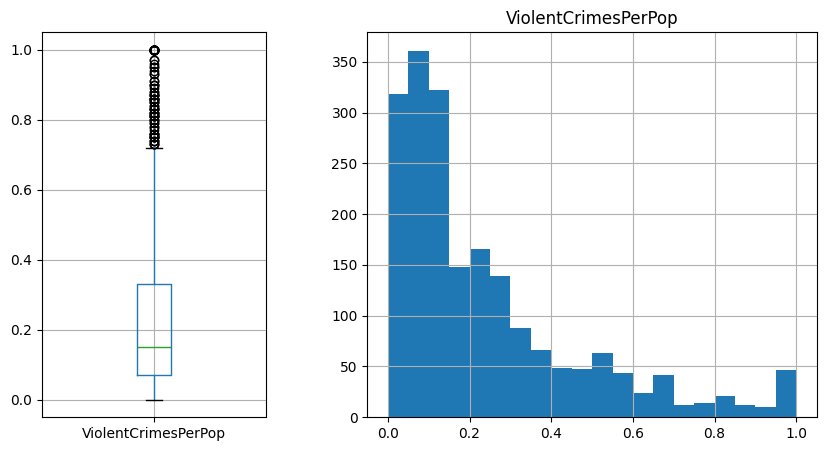

In [14]:
fig, [ax, ay] = plt.subplots(1, 2, figsize=(10, 5),width_ratios=(1/3,2/3 ))
y.boxplot(ax=ax)
y.hist(bins=20, ax=ay)
pass

The crime rate is highly skewed towards small values. This is to be expected of violent crime statistics, because while it may be a problem it is till quite rare. This heavy skewness can violate the assumptions of normality of many models. While it may not be possible to get a normal distribution, it could be less skewed and therefore allow the models to achieve higher performance. 

For this, a `PowerTransformer` will be used. This transformer will apply a transformation to the value to improve the distribution which can be reversed when reading values predicted by models. The `PowerTransformer` supports `yeo-johnson` and `box-cox` methods. In this case the `yeo-johnson` method will be used, because the values of the predicted variable are not always $> 0$.

In [16]:
(y.ViolentCrimesPerPop == 0).sum()

np.int64(10)

array([-3.60243095])

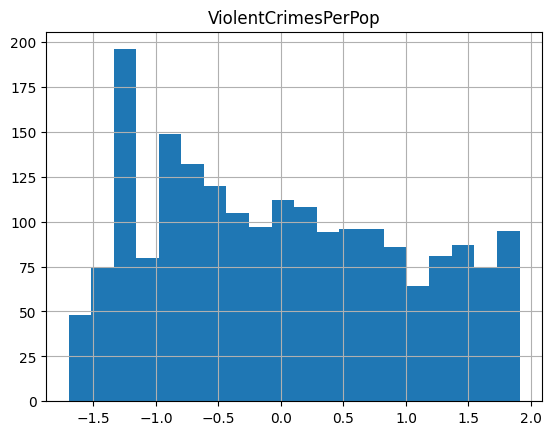

In [3]:
from sklearn.preprocessing import PowerTransformer


y = pd.DataFrame((_ := PowerTransformer('yeo-johnson')).fit_transform(y), columns=y.columns)
y.hist(bins=20)
_.lambdas_

### Missing values

The dataset also contains law enforcement data, but it is from a separate survey that lacks data for most of the samples. This features will be dropped. There is also the matter of `OtherPerCap` which is missing one value. This one samples can just be discarded.

In [18]:
(_ := X.isnull().sum())[_ > 0]

OtherPerCap                1
LemasSwornFT            1675
LemasSwFTPerPop         1675
LemasSwFTFieldOps       1675
LemasSwFTFieldPerPop    1675
LemasTotalReq           1675
LemasTotReqPerPop       1675
PolicReqPerOffic        1675
PolicPerPop             1675
RacialMatchCommPol      1675
PctPolicWhite           1675
PctPolicBlack           1675
PctPolicHisp            1675
PctPolicAsian           1675
PctPolicMinor           1675
OfficAssgnDrugUnits     1675
NumKindsDrugsSeiz       1675
PolicAveOTWorked        1675
PolicCars               1675
PolicOperBudg           1675
LemasPctPolicOnPatr     1675
LemasGangUnitDeploy     1675
PolicBudgPerPop         1675
dtype: int64

In [4]:
X = X.drop((_ := X.isnull().sum())[_ > 1].index, axis=1)
X = X.drop(_ := X[X.OtherPerCap.isnull()].index[0])
y = y.drop(_)
X.shape

(1993, 100)

### Scaling

In this dataset all values were already scaled to a `0..1` range by its creators. 

In [7]:
X.agg(["min", "max"]).T

,min,max
population,0.0,1.0
householdsize,0.0,1.0
racepctblack,0.0,1.0
racePctWhite,0.0,1.0
racePctAsian,0.0,1.0
...,...,...
PctSameState85,0.0,1.0
LandArea,0.0,1.0
PopDens,0.0,1.0
PctUsePubTrans,0.0,1.0


For PCA, Z-score normalization is preferred. This will simultaneously ensure the data is centered and ensure a constant standard deviation.

In [5]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X.agg(["min", "max"])

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn
min,-0.453982,-2.830909,-0.70895,-3.093315,-0.736180,-0.619813,-2.733392,-3.440754,-2.019827,-2.361615,...,-0.226992,-0.933214,-2.980354,-2.950498,-3.124276,-3.286877,-0.59606,-1.146911,-0.706166,-0.391560
max,7.426050,3.277600,3.24664,1.009312,4.051885,3.681776,3.710101,3.525552,3.986253,3.220267,...,9.733284,3.394137,1.915298,2.564787,1.864013,1.758445,8.53989,3.777352,3.659862,3.769575


# Dimensionality reduction

### Principal Component Analysis (PCA)

PCA will transform the data into a number of components. The goal is to set the number to capture the most amount of variance, while still getting a useful reduction in features. First, `PCA` will be applied with the maximum number of components possible, which is $\min(\texttt{n\_samples}, \texttt{n\_features}) - 1$. The cumulative explained variance will be evaluated until it reaches a satisfactory level and this will become the chosen number of components.

In [21]:
from sklearn.decomposition import PCA

pca = PCA(random_state=4221)
pca.fit(X)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

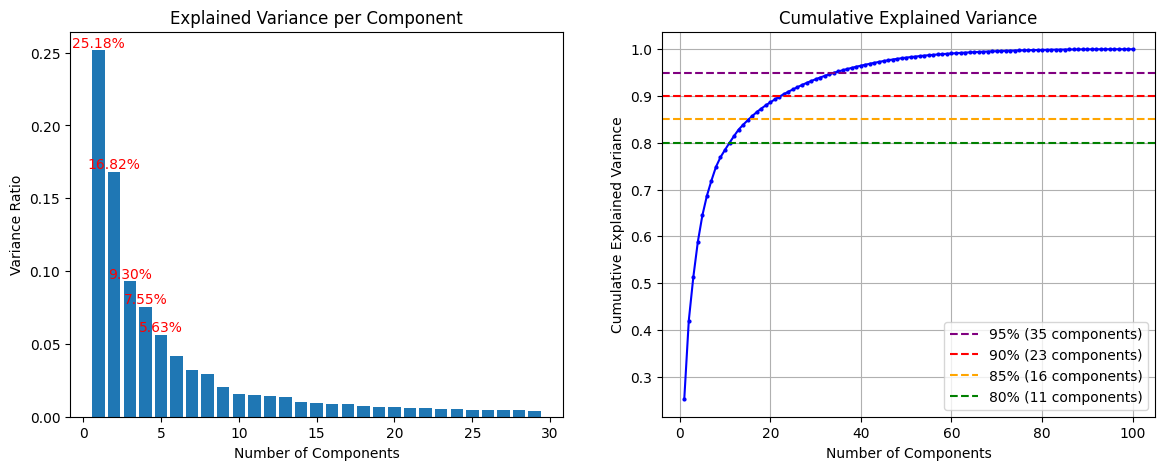

In [22]:
ax: "plt.Axes"
ay: "plt.Axes"
fig, [ax, ay] = plt.subplots(1, 2, figsize=(14, 5))

ax.set_title("Explained Variance per Component")
bars = ax.bar(range(1, 30), pca.explained_variance_ratio_[:29])
ax.set_xlabel("Number of Components")
ax.set_ylabel("Variance Ratio")
ax.bar_label(bars, labels=[f"{v*100:.2f}%" for v in pca.explained_variance_ratio_[:5]], fmt="", color="r")

ay.set_title("Cumulative Explained Variance")
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
ay.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-o', markersize=2)
ay.set_xlabel('Number of Components')
ay.set_ylabel('Cumulative Explained Variance')
ay.axhline(y=0.95, color='purple', linestyle='--', label=f'95% ({np.argmax(cumulative_variance >= 0.95) + 1} components)')
ay.axhline(y=0.90, color='r', linestyle='--', label=f'90% ({np.argmax(cumulative_variance >= 0.90) + 1} components)')
ay.axhline(y=0.85, color='orange', linestyle='--', label=f'85% ({np.argmax(cumulative_variance >= 0.85) + 1} components)')
ay.axhline(y=0.80, color='g', linestyle='--', label=f'80% ({np.argmax(cumulative_variance >= 0.80) + 1} components)')
ay.legend()
ay.grid()

The cumulative explained variance reaches $90\%$ at `23` components. To achieve $95\%$ would require additional `15` components which does not seem worth it. Therefore `23` components will be used. 

In [45]:
print(cumulative_variance[23])

0.9092396620081101


In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=23, random_state=4221)
pca.fit(X)
X_pca = pca.transform(X)

### Partial Least Squares (PLS)

While PCA only looks at the variance within features, PLS also considers their correlation with the predicted variable.

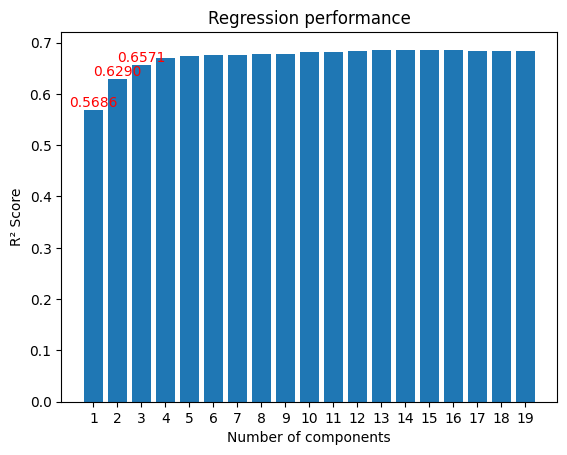

In [24]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score

plot_x = []
plot_y = []

for i in range(1, 20):
    pls = PLSRegression(n_components=i, scale=False)
    score = cross_val_score(pls, X, y).mean()
    plot_x.append(i)
    plot_y.append(score)

fig, ax = plt.subplots(1, 1)

ax.set_title("Regression performance")
ax.set_xlabel("Number of components")
ax.set_ylabel("R² Score")
bars = ax.bar(plot_x, plot_y)
ax.bar_label(bars, labels=[f"{v:.4f}" for v in plot_y[:3]], fmt="", color="r")
ax.set_xticks(plot_x)
pass

The number of components before diminishing returns show is `3`.

In [7]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=3, scale=False)
pls.fit(X, y)
X_pls = pls.transform(X)

### LinearDiscriminantAnalysis (LDA)

While not being designed for continuous output value, LDA can be used by discretizing the predicted variable. As to how many discrete classes to create, the best count will be discovered by searching for when the last (least important) component begins to have minimal explained variance, suggesting diminishing returns.

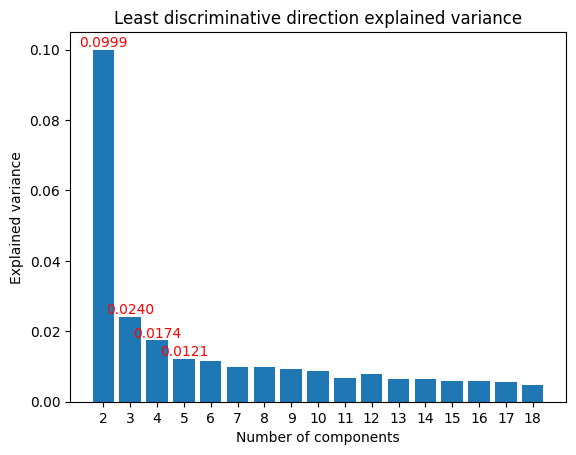

In [27]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

plot_x = []
plot_y = []

for i in range(3, 20):
    y_binned = pd.qcut(y.iloc[:,0], q=i, labels=False, duplicates='drop')
    actual_classes = len(np.unique(y_binned))

    # If some of the classes don't have representative values, abort
    if actual_classes != i:
        print(f"Skipping {i} ({actual_classes})")
        continue
    
    # The maximum count of components is equal to the number of classes - 1
    max_lda_components = actual_classes - 1
    lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
    lda.fit_transform(X, y_binned)
    plot_x.append(max_lda_components)
    plot_y.append(lda.explained_variance_ratio_[-1])

fig, ax = plt.subplots(1, 1)

ax.set_title("Least discriminative direction explained variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Explained variance")
bars = ax.bar(plot_x, plot_y)
ax.bar_label(bars, labels=[f"{v:.4f}" for v in plot_y[:4]], fmt="", color="r")
ax.set_xticks(plot_x)
pass

Considering the chart using the elbow method, `3` components seem to be the a good candidate.

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

y_binned = pd.qcut(y.iloc[:,0], q=4, labels=False, duplicates='drop')
actual_classes = len(np.unique(y_binned))

max_lda_components = actual_classes - 1
lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
X_lda = lda.fit_transform(X, y_binned)

# Model comparison

First, we'll try out all models with both original data and the dimensionally reduced datasets. The defaults setting will be kept for now, they will be refined where applicable based on the initial results.

In [9]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso

models = [
    # ===== Parametric =====

    # Partial least squares regression should handle the large amount of features. It reduces
    # the predictors by also using the response value, so it may have better results that just
    # learning on features reduced without supervision.
    PLSRegression(),
    # Elastic net combines L1 and L2 regularisation from lasso and ridge methods while
    # reportedly being more accurate than both. ElasticNetCV should find the correct values of
    # `alpha` and `l1_ratio`.
    ElasticNetCV(n_jobs=-1, random_state=2611),
    # The linear regression is expected to have problems, considering the large amount of features with
    # high collinearity, but using the reduced feature space, it may produce good outputs while
    # having high explainability.
    LinearRegression(),


    # ===== Nonparametric =====
    
    # Despite being nonparametric, a decision tree is simple to explain.
    DecisionTreeRegressor(random_state=2611),
    # If a single decision tree is insufficient, a random forest may be required. Random forest
    # also provides a validation set from OOB samples, but in the interest of having universal
    # testing code it will not be used.
    RandomForestRegressor(oob_score=False, n_jobs=-1, random_state=2611),
    # Another attempt to improve decision tree performance (by default gradient boosting uses decision trees).
    GradientBoostingRegressor(random_state=2611),
    # kNN will be probably hopeless with the full dataset, but with the dimensionality reduced
    # datasets it could work. kNN regression is good when there are clusters of similar data,
    # but no global trend, which may be useful for this dataset which models human behaviour
    # across a large area.
    KNeighborsRegressor()
]

In [10]:
from typing import Any

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

def test_model[T: Any](name: str, model: T, x: Any = X, y = y) -> tuple[T, float]:
    X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=9138)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    print(f"{name} : R²: {r2:.4f}")

    return model, r2

def test_performance(
    datasets = [
        ("All", X),
        ("PCA", X_pca),
        ("PLS", X_pls),
        ("LDA", X_lda),
    ],
    models=models,
    callback = None
):

    performance = pd.DataFrame(columns=[v for v, _ in datasets], index=[(v[0] if isinstance(v, tuple) else v.__class__.__name__)  for v in models])

    for dataset_name, X_dataset in datasets:
        print(f"-- {dataset_name}")
        for model in models:
            model_name = model.__class__.__name__
            
            if isinstance(model, tuple):
                model_name, model = model

            _, r2 = test_model(model_name, model, X_dataset)

            if callback:
                callback(model)

            performance.at[model_name, dataset_name] = r2

    return performance


In [61]:
performance = test_performance()
performance

-- All
PLSRegression : R²: 0.6191
ElasticNetCV : R²: 0.6655
LinearRegression : R²: 0.6735
DecisionTreeRegressor : R²: 0.3287
RandomForestRegressor : R²: 0.6929
GradientBoostingRegressor : R²: 0.7022
KNeighborsRegressor : R²: 0.6201
-- PCA
PLSRegression : R²: 0.6561
ElasticNetCV : R²: 0.6577
LinearRegression : R²: 0.6562
DecisionTreeRegressor : R²: 0.2070
RandomForestRegressor : R²: 0.6700
GradientBoostingRegressor : R²: 0.6792
KNeighborsRegressor : R²: 0.6077
-- PLS
PLSRegression : R²: 0.6486
ElasticNetCV : R²: 0.6486
LinearRegression : R²: 0.6486
DecisionTreeRegressor : R²: 0.4389
RandomForestRegressor : R²: 0.6541
GradientBoostingRegressor : R²: 0.6792
KNeighborsRegressor : R²: 0.6561
-- LDA
PLSRegression : R²: 0.6979
ElasticNetCV : R²: 0.6977
LinearRegression : R²: 0.6979
DecisionTreeRegressor : R²: 0.4779
RandomForestRegressor : R²: 0.6981
GradientBoostingRegressor : R²: 0.7017
KNeighborsRegressor : R²: 0.6677


,All,PCA,PLS,LDA
PLSRegression,0.619097,0.656098,0.648615,0.697932
ElasticNetCV,0.66546,0.657668,0.648606,0.697723
LinearRegression,0.673549,0.656159,0.64862,0.697932
DecisionTreeRegressor,0.328712,0.207017,0.438942,0.477883
RandomForestRegressor,0.692947,0.669993,0.654133,0.698122
GradientBoostingRegressor,0.702188,0.679207,0.679185,0.701739
KNeighborsRegressor,0.620058,0.607725,0.656102,0.667748


<Axes: ylabel='R² Score'>

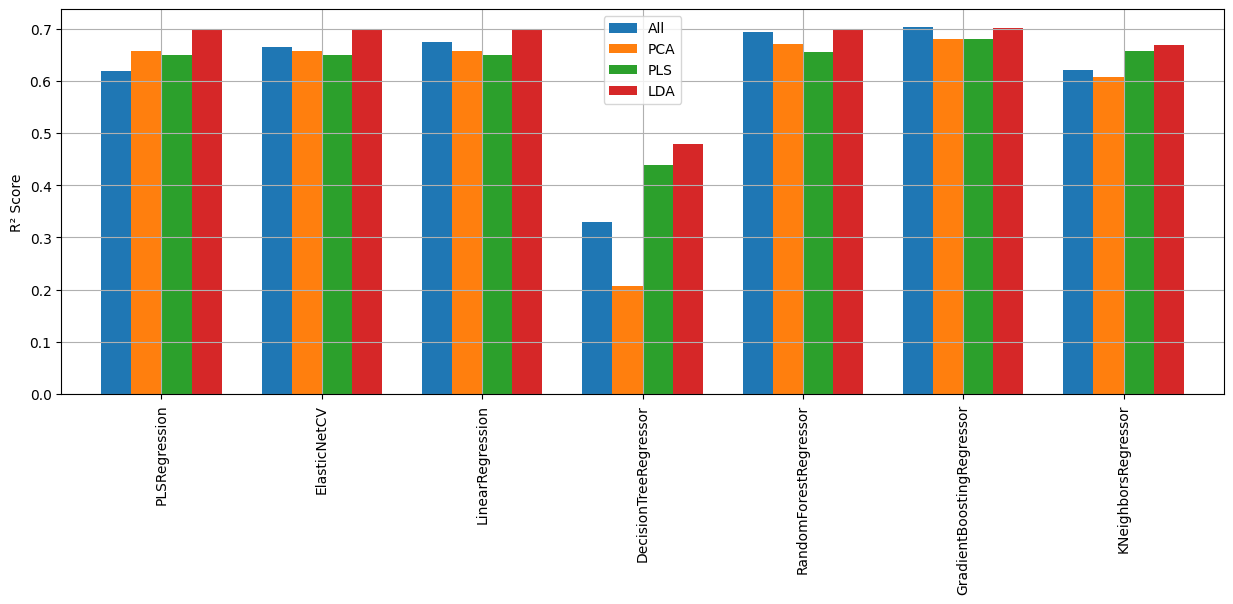

In [62]:
performance.plot.bar(figsize=(15, 5), width=0.75, grid=True, ylabel="R² Score")

The many cases where `PCA` and `PLS` methods achieved worse performance than all features suggest that some information loss is occurring, but this is not universal, as `DecisionTreeRegressor` and `KNeighboursRegressor` achieved superior performance from `PLS` than with all features.

Nevertheless, it seems LDA dimensional reduction allowed the models to better fit the data. LDA displays the best results, even in the case, where it is inferior to using all features (`GradientBoostingRegressor`), the difference is only two tenths of a percent. Therefore, for fine tuning the model hyperparameters, it will be used to evaluate the changes.

It is interesting that `PLSRegression` performs significantly worse on all features than the dimensionally reduced datasets, considering it does its own dimensional reduction. This is in contrast to `ElasticNetCV` which does features selection (to a limited degree due to L2 regularisation) and appears to have done a better job than `PCA` and `PLC`, achieving better performance when having access to all features. `LDA` dimensional reduction still dominates though.

Overall even though `DecisionTreeRegressor` didn't perform well, ensemble methods did. This shows that using many trees said methods managed to capture the 

### Performance of RandomForestRegressor

By default the `RandomForestRegressor` uses 100 trees. The performance could be improved by adjusting this count.

-- LDA
50 : R²: 0.6948
100 : R²: 0.6981
150 : R²: 0.6991
200 : R²: 0.7005
250 : R²: 0.7005
300 : R²: 0.6995


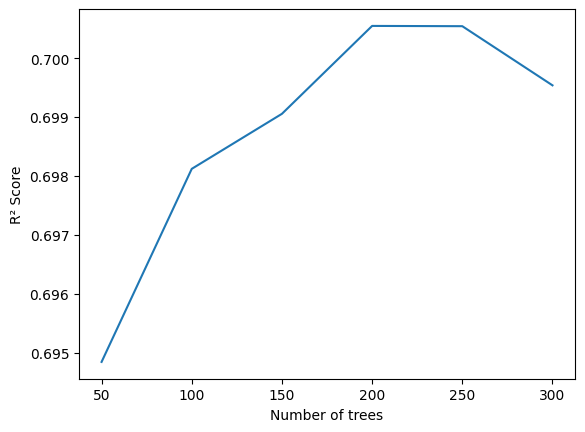

In [ ]:
test_performance([("LDA", X_lda)], [(f"{i}", RandomForestRegressor(n_estimators=i, oob_score=False, n_jobs=-1, random_state=2611)) for i in range(50, 350, 50)]).plot(ylabel="R² Score", xlabel="Number of trees", legend=False)
pass

By default the model will expand nodes until they are all pure. Try to make smaller trees to overfitting.

-- LDA
3 : R²: 0.7002
4 : R²: 0.7061
5 : R²: 0.7109
6 : R²: 0.7121
7 : R²: 0.7113
8 : R²: 0.7103
9 : R²: 0.7091
None : R²: 0.7005


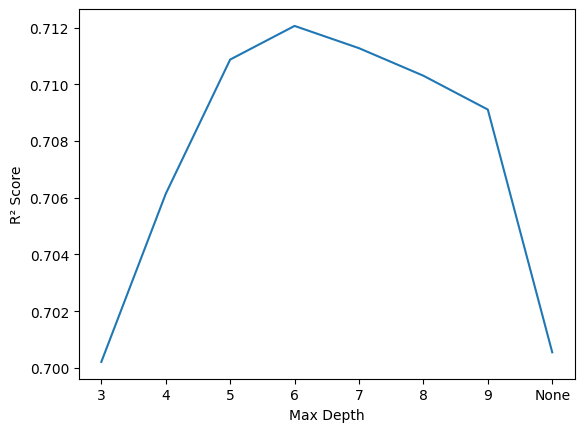

In [28]:
test_performance([("LDA", X_lda)], [(f"{i}", RandomForestRegressor(n_estimators=200, max_depth=i, oob_score=False, n_jobs=-1, random_state=2611)) for i in [*range(3, 10), None]]).plot(ylabel="R² Score", xlabel="Max Depth", legend=False)
pass

By default the `RandomForestRegressor` trains each tree on all samples. With `max_samples` this can adjusted.

-- LDA
0.1 : R²: 0.7119
0.2 : R²: 0.7113
0.3 : R²: 0.7144
0.4 : R²: 0.7148
0.5 : R²: 0.7127
0.6 : R²: 0.7132
0.7 : R²: 0.7132
0.8 : R²: 0.7140
0.9 : R²: 0.7137


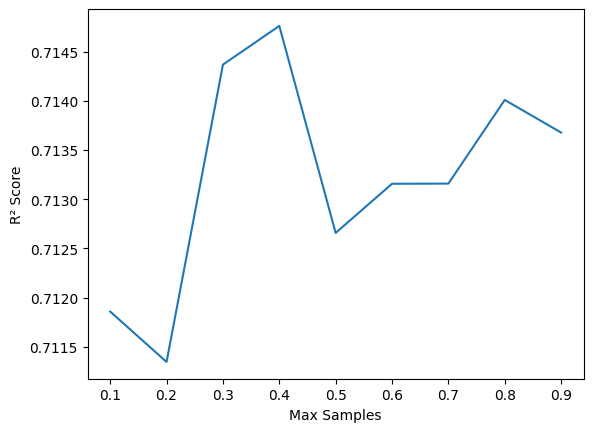

In [29]:
test_performance([("LDA", X_lda)], [(f"{i:.1f}", RandomForestRegressor(n_estimators=200, max_depth=6, max_samples=i, oob_score=False, n_jobs=-1, random_state=2611)) for i in np.arange(0.1, 1, 0.1)]).plot(ylabel="R² Score", xlabel="Max Samples", legend=False)
pass

The differences between values are very small, but it seems `0.4` is the best performing percentage. 

Next parameter to evaluate is `criterion`. The default value is `squared_error`. According to the documentation `absolute_error` has better results at the cost of taking longer to compute. For this small dataset, that should not be an issue. Also, the other possible will be evaluated, but not `poisson` because it can't predict negative values.

-- LDA
absolute_error : R²: 0.7143
friedman_mse : R²: 0.7147
squared_error : R²: 0.7148


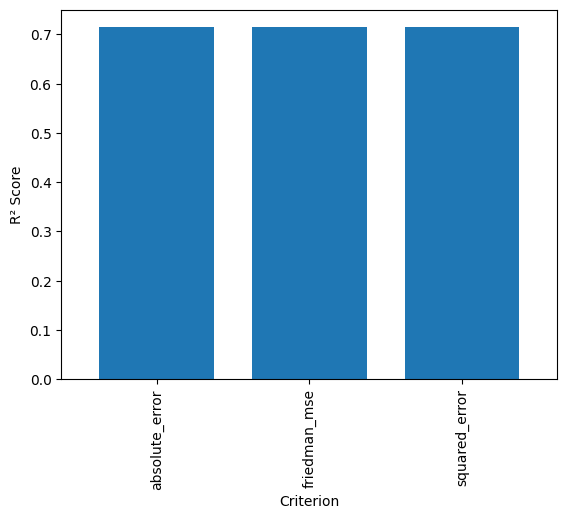

In [31]:
test_performance([("LDA", X_lda)], [(i, RandomForestRegressor(n_estimators=200, max_depth=6, max_samples=0.4, criterion=i, oob_score=False, n_jobs=-1, random_state=2611)) for i in ["absolute_error", "friedman_mse", "squared_error"]]).plot.bar(ylabel="R² Score", xlabel="Criterion", legend=False, width=0.75)
pass

The change is minimal, but the `squared_error` criterion is the best.

### Performance of GradientBoostingRegressor

The most influential parameters are `n_estimators` and `learning_rate`. Changing each counteracts a change in the other, so test out multiple counts of estimators at different learning rates.

-- LDA
10 : R²: 0.6958
15 : R²: 0.7077
20 : R²: 0.7107
25 : R²: 0.7076
30 : R²: 0.7045
35 : R²: 0.7055
40 : R²: 0.7057
45 : R²: 0.7055
50 : R²: 0.7056
100 : R²: 0.6981
150 : R²: 0.6973
200 : R²: 0.6976
250 : R²: 0.6950
300 : R²: 0.6937


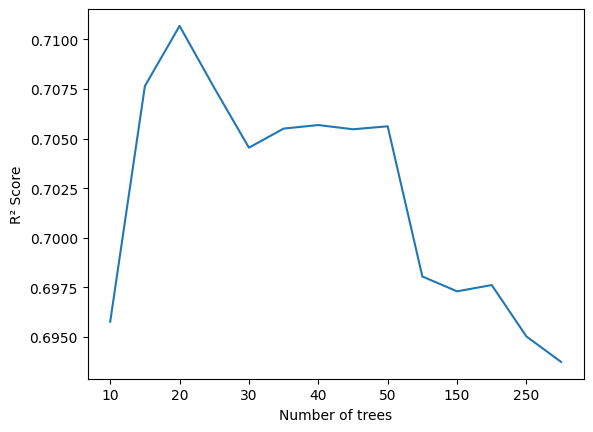

In [38]:
test_performance([("LDA", X_lda)], [(f"{i}", GradientBoostingRegressor(n_estimators=i, learning_rate=0.2, random_state=2611)) for i in [*range(10, 50, 5), *range(50, 350, 50)]]).plot(ylabel="R² Score", xlabel="Number of trees", legend=False)
pass

-- LDA
10 : R²: 0.6090
20 : R²: 0.6955
30 : R²: 0.7105
40 : R²: 0.7096
50 : R²: 0.7085
100 : R²: 0.7017
150 : R²: 0.6988
200 : R²: 0.6940
250 : R²: 0.6910
300 : R²: 0.6928


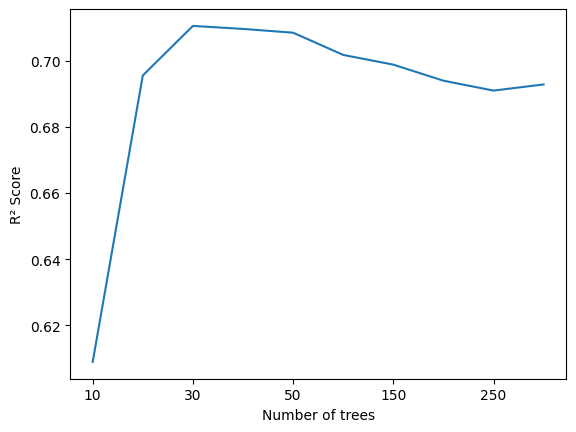

In [33]:
test_performance([("LDA", X_lda)], [(f"{i}", GradientBoostingRegressor(n_estimators=i, random_state=2611)) for i in [*range(10, 50, 10), *range(50, 350, 50)]]).plot(ylabel="R² Score", xlabel="Number of trees", legend=False)
pass

-- LDA
10 : R²: 0.4396
20 : R²: 0.6042
30 : R²: 0.6680
40 : R²: 0.6936
50 : R²: 0.7043
100 : R²: 0.7099
150 : R²: 0.7076
200 : R²: 0.7042
250 : R²: 0.7016
300 : R²: 0.6990


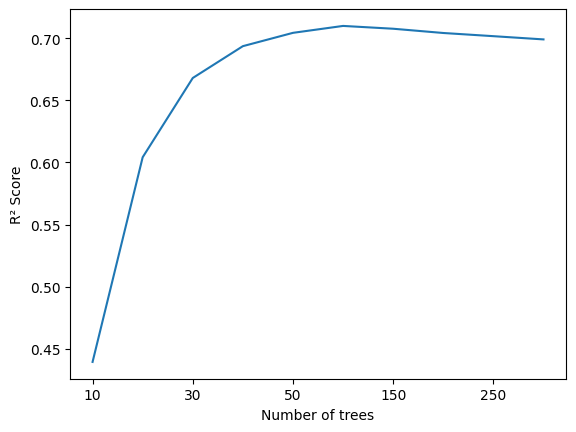

In [34]:
test_performance([("LDA", X_lda)], [(f"{i}", GradientBoostingRegressor(n_estimators=i, learning_rate=0.05, random_state=2611)) for i in [*range(10, 50, 10), *range(50, 350, 50)]]).plot(ylabel="R² Score", xlabel="Number of trees", legend=False)
pass

-- LDA
50 : R²: 0.4344
100 : R²: 0.6003
150 : R²: 0.6654
200 : R²: 0.6921
250 : R²: 0.7036
300 : R²: 0.7086
350 : R²: 0.7098
400 : R²: 0.7103


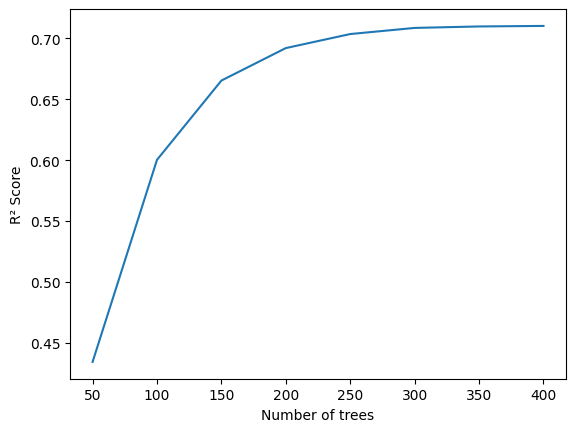

In [36]:
test_performance([("LDA", X_lda)], [(f"{i}", GradientBoostingRegressor(n_estimators=i, learning_rate=0.01, random_state=2611)) for i in [*range(50, 450, 50)]]).plot(ylabel="R² Score", xlabel="Number of trees", legend=False)
pass

With the `learning_rate` of `0.01`, diminishing returns are encountered above `300` with $R^2$ increase of `0.001` followed by `0.0005`. With `learning_rate` of `0.05`, the model seemingly begins overfitting at `100` estimators. With `learning_rate` of `0.1` (the default), we reach the best performance at `30` estimators. With `learning_rate` of `0.2` the model overfits quickly, but also reaches the global best at `20` estimators.

The `GradientBoostingRegressor` sets the `max_depth` to `3` by default, but there is a possibility there is a better option.

-- LDA
1 : R²: 0.6951
2 : R²: 0.7090
3 : R²: 0.7107
4 : R²: 0.7037
5 : R²: 0.7009
6 : R²: 0.6957
7 : R²: 0.6898
8 : R²: 0.6802
9 : R²: 0.6645
None : R²: 0.5032


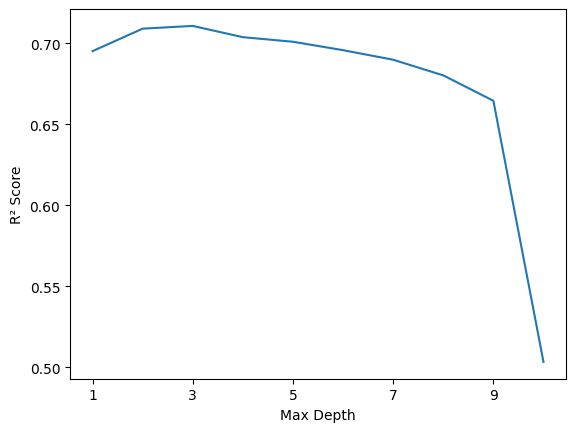

In [40]:
test_performance([("LDA", X_lda)], [(f"{i}", GradientBoostingRegressor(n_estimators=20, learning_rate=0.2, max_depth=i, random_state=2611)) for i in [*range(1, 10), None]]).plot(ylabel="R² Score", xlabel="Max Depth", legend=False)
pass

It appears the default value of `3` is the best.

`GradientBoostingRegressor` also has an option to only use a fraction of samples for each iteration. This can reduce overfitting and also makes the learning process faster (thought, this is not a factor for this project, considering the size of the dataset). This feature is disabled by default.

-- LDA
0.10 : R²: 0.7081
0.15 : R²: 0.6974
0.20 : R²: 0.7101
0.25 : R²: 0.6958
0.30 : R²: 0.6925
0.35 : R²: 0.7040
0.40 : R²: 0.7034
0.45 : R²: 0.7043
0.50 : R²: 0.7033
0.55 : R²: 0.7004
0.60 : R²: 0.7013
0.65 : R²: 0.7047
0.70 : R²: 0.7110
0.75 : R²: 0.7084
0.80 : R²: 0.7079
0.85 : R²: 0.7106
0.90 : R²: 0.7112
0.95 : R²: 0.7047
1.00 : R²: 0.7107


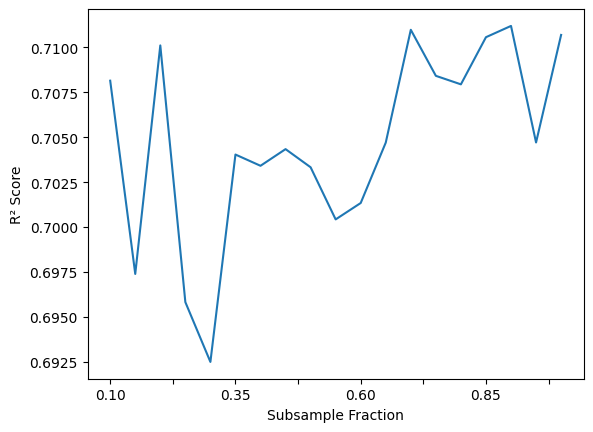

In [49]:
test_performance([("LDA", X_lda)], [(f"{i:.2f}", GradientBoostingRegressor(n_estimators=20, learning_rate=0.2, max_depth=3, subsample=i, random_state=2611)) for i in np.concat([np.arange(0.1, 1, 0.05), [1]])]).plot(ylabel="R² Score", xlabel="Subsample Fraction", legend=False)
pass

The best performance is achieved with `subsample` of `0.9`.

There is also a parameter to set the loss function, which will be optimised. The default is `squared_error`, but others will also be evaluated.

-- LDA
squared_error : R²: 0.7112
absolute_error : R²: 0.7064
huber : R²: 0.7059
quantile : R²: 0.1868


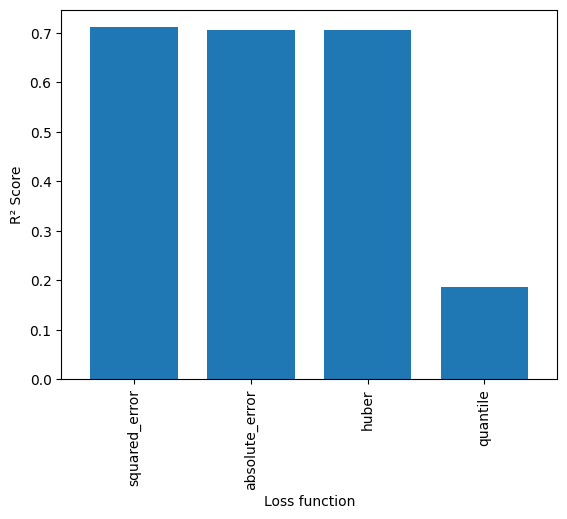

In [50]:
test_performance([("LDA", X_lda)], [(i, GradientBoostingRegressor(n_estimators=20, learning_rate=0.2, max_depth=3, subsample=0.9, loss=i, random_state=2611)) for i in ["squared_error", "absolute_error", "huber", "quantile"]]).plot.bar(ylabel="R² Score", xlabel="Loss function", legend=False, width=0.75)
pass

The default appears to be the best.

### Performance of ElasticNetCV

`ElasticNetCV` tries to optimise the best parameters using cross-validation. The default count is `5`.

-- LDA
5 : R²: 0.6977
10 : R²: 0.6979
15 : R²: 0.6979
20 : R²: 0.6979
25 : R²: 0.6979
30 : R²: 0.6979


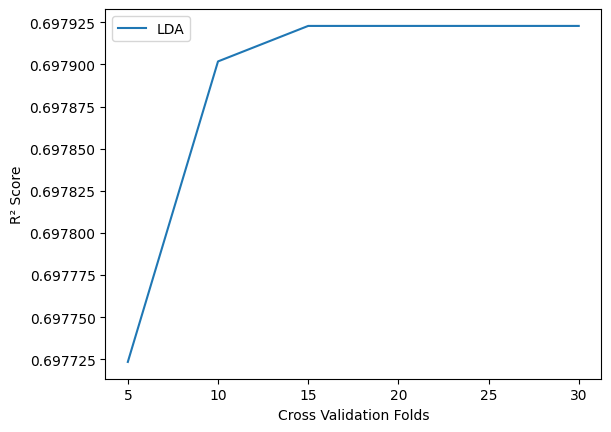

In [69]:
test_performance([("LDA", X_lda)], [(f"{i}", ElasticNetCV(cv=i, n_jobs=-1, random_state=2611)) for i in range(5, 35, 5)]).plot(ylabel="R² Score", xlabel="Cross Validation Folds")
pass

`ElasticNetCV` can also try out multiple L1 ratios, see if we can get a better result than with `0.5`.

-- LDA
5 : R²: 0.6977
L1 Ratio: 1.0, Alpha: 0.010511
10 : R²: 0.6969
L1 Ratio: 1.0, Alpha: 0.026036
15 : R²: 0.6979
L1 Ratio: 1.0, Alpha: 0.001490
20 : R²: 0.6979
L1 Ratio: 1.0, Alpha: 0.001490
25 : R²: 0.6979
L1 Ratio: 1.0, Alpha: 0.001490
30 : R²: 0.6979
L1 Ratio: 1.0, Alpha: 0.001490


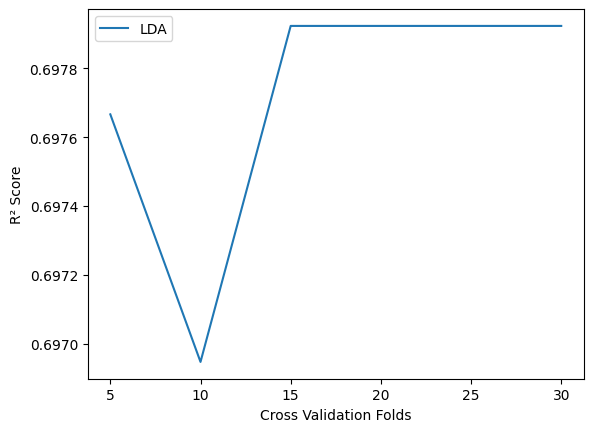

In [68]:
test_performance([("LDA", X_lda)], [(f"{i}", ElasticNetCV(cv=i, n_jobs=-1, l1_ratio=[0.1, 0.2, 0.5, 0.7, 0.9, 0.95, 0.99, 1], random_state=2611)) for i in range(5, 35, 5)], callback=lambda model: print(f"L1 Ratio: {model.l1_ratio_}, Alpha: {model.alpha_:.6f}")).plot(ylabel="R² Score", xlabel="Cross Validation Folds")
pass

Considering the best result for LDA reduced dataset has `l1_ratio` of `1.0`, we can just use a LASSO model with the calculated `alpha` for equivalent performance.

In [ ]:
print(f"Coefficients: {test_model("Lasso", Lasso(alpha=0.001490, random_state=2611), X_lda)[0].coef_}")

Lasso : R²: 0.6979
Coefficients: [ 0.48583694 -0.00851102  0.019347  ]


Out of curiosity, compare the coefficients with simple linear regression. The use of regularisation is used to handle colinearity and there shouldn't be colinearity in the LDA reduced dataset.

In [71]:
print(f"Coefficients: {test_model("LinearRegression", LinearRegression(), X_lda)[0].coef_}")

LinearRegression : R²: 0.6979
Coefficients: [[ 0.48634308 -0.00968906  0.02075221]]


### Performance of KNeighborsRegressor

In [77]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": [1, *range(5, 35, 5)],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(KNeighborsRegressor(n_jobs=-1), param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_lda, y)

print(f"Best parameters: {grid.best_params_}")

Best parameters: {'metric': 'manhattan', 'n_neighbors': 30, 'weights': 'uniform'}


The best `metric` type is `manhattan` with all points being equally weighted. The `n_neighbours` is the max, so there could be diminishing returns.

-- LDA
5 : R²: 0.6721
10 : R²: 0.6945
15 : R²: 0.6921
20 : R²: 0.6957
25 : R²: 0.6948
30 : R²: 0.7028
35 : R²: 0.7063
40 : R²: 0.7097
45 : R²: 0.7081
50 : R²: 0.7111
55 : R²: 0.7085
60 : R²: 0.7087
65 : R²: 0.7103
70 : R²: 0.7094
75 : R²: 0.7086
80 : R²: 0.7078
85 : R²: 0.7070
90 : R²: 0.7067
95 : R²: 0.7067
100 : R²: 0.7063


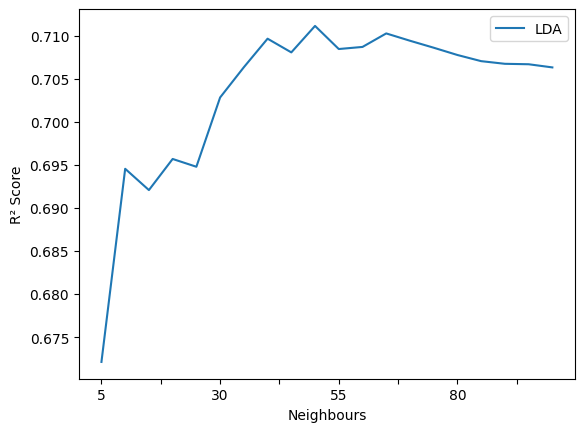

In [76]:
test_performance([("LDA", X_lda)], [(f"{i}", KNeighborsRegressor(metric="manhattan", weights="uniform", n_neighbors=i, n_jobs=-1)) for i in range(5, 105, 5)]).plot(ylabel="R² Score", xlabel="Neighbours")
pass

The best `n_neighbours` is `50`, which is followed by diminishing returns and eventual overfitting.

### Applying tuned hyperparameters

Now that the hyperparameters for best performance have been found, use them again for the final evaluation of models.

-- All
PLSRegression : R²: 0.6191
Lasso : R²: 0.6683
LinearRegression : R²: 0.6735
DecisionTreeRegressor : R²: 0.3287
RandomForestRegressor : R²: 0.6925
GradientBoostingRegressor : R²: 0.6856
KNeighborsRegressor : R²: 0.6462
-- PCA
PLSRegression : R²: 0.6561
Lasso : R²: 0.6568
LinearRegression : R²: 0.6562
DecisionTreeRegressor : R²: 0.2070
RandomForestRegressor : R²: 0.6447
GradientBoostingRegressor : R²: 0.6551
KNeighborsRegressor : R²: 0.6211
-- PLS
PLSRegression : R²: 0.6486
Lasso : R²: 0.6486
LinearRegression : R²: 0.6486
DecisionTreeRegressor : R²: 0.4389
RandomForestRegressor : R²: 0.6738
GradientBoostingRegressor : R²: 0.6782
KNeighborsRegressor : R²: 0.6692
-- LDA
PLSRegression : R²: 0.6979
Lasso : R²: 0.6979
LinearRegression : R²: 0.6979
DecisionTreeRegressor : R²: 0.4779
RandomForestRegressor : R²: 0.7148
GradientBoostingRegressor : R²: 0.7112
KNeighborsRegressor : R²: 0.7111


,All,PCA,PLS,LDA
PLSRegression,0.619097,0.656098,0.648615,0.697932
Lasso,0.668344,0.656848,0.648616,0.697923
LinearRegression,0.673549,0.656159,0.64862,0.697932
DecisionTreeRegressor,0.328712,0.207017,0.438942,0.477883
RandomForestRegressor,0.692464,0.64471,0.673823,0.714763
GradientBoostingRegressor,0.685629,0.655098,0.678228,0.711184
KNeighborsRegressor,0.646209,0.621087,0.66923,0.711136


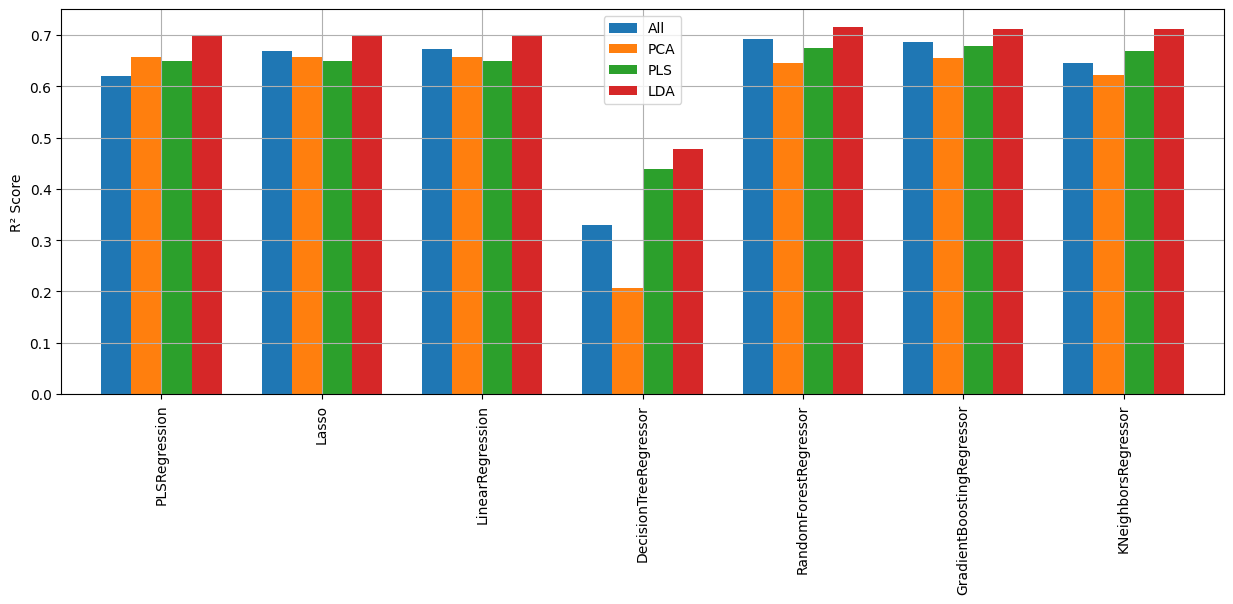

In [ ]:
models = [
    # ===== Parametric =====

    PLSRegression(),
    Lasso(alpha=0.001490, random_state=2611),
    LinearRegression(),


    # ===== Nonparametric =====
    
    DecisionTreeRegressor(random_state=2611),
    RandomForestRegressor(n_estimators=200, max_depth=6, max_samples=0.4, criterion="squared_error", oob_score=False, n_jobs=-1, random_state=2611),
    GradientBoostingRegressor(n_estimators=20, learning_rate=0.2, max_depth=3, subsample=0.9, loss="squared_error", random_state=2611),
    KNeighborsRegressor(metric="manhattan", weights="uniform", n_neighbors=50, n_jobs=-1)
]

(_ := test_performance(models=models)).plot.bar(figsize=(15, 5), width=0.75, grid=True, ylabel="R² Score")
_

While adjustments of hyperparameters have worsened the performance of several cases, because they were optimised for the `LDA` reduced dataset, the performance of ensemble decision tree methods and kNN has improved, reaching $R^2$ of $71\%$.

# Explainability & Reproducibility

In terms of explainability, the ElasticNetCV model is the best. Because it uses linear regression, we can simply look at how much each feature impacts the resulting value. This won't work very well with all features, where collinearity makes it hard to trust the individual coefficients, it will be useful with LDA dimensionality reduction, where the LDA features can be mapped back to the original ones. In terms of reproducibitlity with LDA dimensionality reduction, the best performance is achieved with `l1_ratio` of `1`, therefore L1 regularisation will be used, and in cases of collinearity, one feature will be picked arbitrarily and others suppressed. But that is unlikely to matter, because there shouldn't be colinear features in the dimensionally reduced dataset anyway — in that case the reproducibility relies on the reproducibility of LDA.

But, as experiments show, manually removing the least significant feature from the dimensionally reduced dataset makes `LinearRegression` achieve comparable performance. It stands to reason that this would be the most explainable and reproducible model.

DecisionTreeRegressor is also very explainable, but has significantly inferior performance, so conclusion drawn from it may. Improvements upon it, like RandomForestRegressor could be used for interpretation, using features importance for each feature across the whole forrest or with dependence plots. Reproducibility is also maintained by using a constant `random_state`.

KNeighborsRegressor also has great performance but does not help to understand the data at all, because it does not learn and instead only compares inputs to known values for prediction.

For best explainability we would use the `LinearRegression` model with the first three most significant features from LDA. This provides the best performance while showing the coefficients for each feature which can be mapped back to the original features. Another model useful for explainability is `RandomForestRegressor` which, while not being as easy to interpret as numeric coefficients, may show non-linear relationships.


### Mapping dimensionally reduced features back to original

In [ ]:
def map_back_to_original(coef: np.ndarray = np.array([1])):
    # The 'scalings_' attribute shows the contribution of original features to the LDA components.
    scalings = lda.scalings_

    weighted_loadings = scalings * coef

    df_loadings = pd.DataFrame(weighted_loadings, index=X.columns, columns=[f"LD{i+1}" for i in range(scalings.shape[1])])
    df_loadings["Effect"] = df_loadings.sum(axis=1)

    display(df_loadings.sort_values(by="Effect", key=abs, ascending=False).head(10).style.set_caption("Sort by: Effect"))
    display(df_loadings[["LD1"]].sort_values(by="LD1", key=abs, ascending=False).head(10).style.set_caption("Features in: LD1"))
    display(df_loadings[["LD2"]].sort_values(by="LD2", key=abs, ascending=False).head(10).style.set_caption("Features in: LD2"))
    display(df_loadings[["LD3"]].sort_values(by="LD3", key=abs, ascending=False).head(10).style.set_caption("Features in: LD3"))

In [ ]:
map_back_to_original()

,LD1,LD2,LD3,Effect
medIncome,-0.786400,-0.264870,-2.421079,-3.472349
medFamInc,1.029673,0.107645,2.236535,3.373853
TotalPctDiv,-0.044833,0.680324,-3.543897,-2.908406
PctRecImmig10,-1.149341,1.398407,2.634455,2.883521
whitePerCap,-0.131312,-0.498037,-1.640290,-2.269639
FemalePctDiv,0.043911,-0.419650,2.441505,2.065765
MedRent,0.283415,1.556863,-0.140565,1.699713
agePct12t29,-0.133948,-0.500675,-0.832364,-1.466986
PctRecImmig5,0.059766,-0.250376,-1.179251,-1.369861
RentHighQ,0.021136,-1.041970,-0.305837,-1.326670


,LD1
population,1.918275
numbUrban,-1.576518
PctRecImmig8,1.191533
PctRecImmig10,-1.149341
PersPerOccupHous,1.140189
PctPersOwnOccup,-1.075867
medFamInc,1.029673
PctKids2Par,-0.990273
PctHousOwnOcc,0.921707
medIncome,-0.786400


,LD2
population,-2.589997
numbUrban,2.024863
MedRent,1.556863
PctRecImmig10,1.398407
PctKids2Par,1.211243
PersPerOccupHous,1.122883
PersPerRentOccHous,-1.118721
OwnOccMedVal,1.057188
RentHighQ,-1.041970
PctRecImmig8,-0.979197


,LD3
TotalPctDiv,-3.543897
PctRecImmig10,2.634455
FemalePctDiv,2.441505
medIncome,-2.421079
medFamInc,2.236535
OwnOccMedVal,-1.994127
PctHousOwnOcc,-1.828932
whitePerCap,-1.640290
PctPersOwnOccup,1.557824
PctRecImmig8,-1.427863


In [ ]:
X[["MalePctDivorce", "FemalePctDiv", "TotalPctDiv"]].corrwith(X.PctKids2Par)

MalePctDivorce   -0.710124
FemalePctDiv     -0.730015
TotalPctDiv      -0.740173
medFamInc         0.709670
dtype: float64

In [ ]:
print(X[["PctRecImmig10"]].corrwith(X.PctRecImmig8))
X[["racepctblack", "racePctWhite", "racePctAsian", "racePctHisp"]].corrwith(X.PctRecImmig10)

PctRecImmig10    0.995524
dtype: float64


racepctblack   -0.018925
racePctWhite   -0.451832
racePctAsian    0.672977
racePctHisp     0.681116
dtype: float64

In [19]:
X[["householdsize"]].corrwith(X.PersPerOccupHous)

householdsize    0.892973
dtype: float64

In [23]:
X[["RentHighQ"]].corrwith(X.MedRent)

RentHighQ    0.977161
dtype: float64

In [52]:
X[["medFamInc"]].corrwith(X.medIncome)

medFamInc    0.977597
dtype: float64

#### `LD1`

  - This feature scales highly with `population`, but inversely with `numbUrban` (number of people living urban areas), suggesting highly populated rural areas.
  - It also scales with `PersPerOccupHous` (mean count of people in households) and inversely with `PctPersOwnOccup` (percent of people in owner occupied households, i.e. not rented), suggesting counties with unaffordable housing — large counts of people living in one place which is rented.
  - These counties have higher `medFamInc` (median family income) but lower `medIncome` (median income) suggesting families with many earners, could be multi-generational living arrangements.
  - These counties have lower `PctKids2Par` (percent of kids with two parents), suggesting a larger rate of divorce.
  - Negatively correlated with old immigration `PctRecImmig10` but not recent`PctRecImmig8`

Overall, these factors point towards `LD1` representing rural and highly populated counties with low standards of living, pushing people towards cohabitation, children staying with their families due to difficulty of home ownership.

#### `LD2`

  - This feature represents less populated (negative `population`) urban areas (positive `numbUrban`)
  - There is a large fraction of people owning their homes (positive `PersPerOccupHous` while negative `PersPerRentOccHous`), despite median property values being high (positive `OwnOccMedVal` — owner occupied housing median value)
  - Stable families (positive `PctKids2Par`)
  - Positively correlated with old immigration `PctRecImmig10` but not recent`PctRecImmig8`
  - There is high rent (positive `MedRent` — median gross rent) but not the highest (negative `RentHighQ` — upper quartile rent).

#### `LD3`

  - `TotalPctDiv` (percent of divorced people, any gender) is negative while `FemalePctDiv` (percent of women divorced) is positive
  - Interestingly `whitePerCap` (per capita income for caucasians) is negatively correlated
  - Other factors concerning income and home ownership are similar to `LD1`
  - But, as opposed to `LD1`, positively correlated with old immigration `PctRecImmig10` but not recent`PctRecImmig8`

In addition to factors captured by `LD1`, this component seems to be capturing some kind of specific pattern that's hard to describe. The old immigration may suggest immigrants already well integrated.

#### Summary

  - `LD1` ⇒ signifies poor rural areas with high populations and large but unstable family structures, recent immigration
  - `LD2` ⇒ signifies rich urban neighbourhoods with stable families, old but not recent immigration
  - `LD3` ⇒ similar to `LD1`, but lower income for white people and well integrated immigrant population

In [35]:
pd.DataFrame(X_lda).corrwith(y.ViolentCrimesPerPop)

0    0.070142
1   -0.021015
2   -0.031382
dtype: float64

Primitive analysis suggests that rural communities with low standards of living are prone to violent crime, but this information is not sufficient for a conclusion. Let's see how these relationships are understood by ML models.

### Determining violent crime factors

To see the significance of each components, the coefficients of a model like `LinearRegression` can be used to assign weight to each component.

In [55]:
reg = test_model(f"LinearRegression", LinearRegression(), X_lda)[0]
print(reg.coef_)


LinearRegression : R²: 0.6979
[[ 0.48634308 -0.00968906  0.02075221]]


`LinearRegression` has similar conclusions about `LD1` compared to simply correlation. However, it considers `LD3` to be much more significant than `LD2`. Interestingly, the sign of `LD3` suggest that it is positively correlated with violent crime ­— this makes sense considering that `LD3` is affected by similar features as `LD1`, but it can also be the case that there is a non-linear relationship that is not properly captured by this coefficient.

To see non-linear relationship, partial dependence displays will be used to graph how a feature impacts the predicted value throughout its range. As a model `RandomForestRegressor` will be used. This model can capture non-linear relationships and by its nature of averaging results from multiple trees, smoother values that are easier to interpret can be obtained.

RandomForest : R²: 0.7148
[0.90533524 0.05596332 0.03870144]


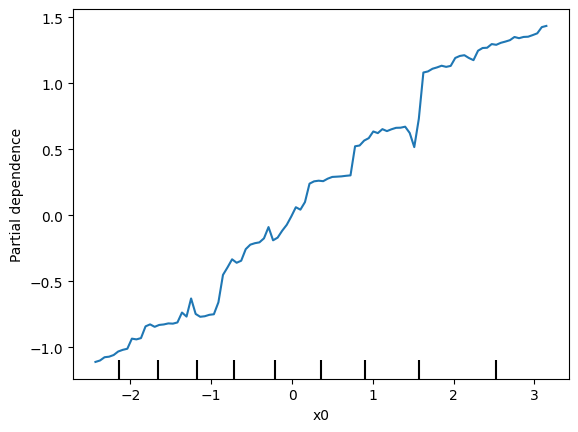

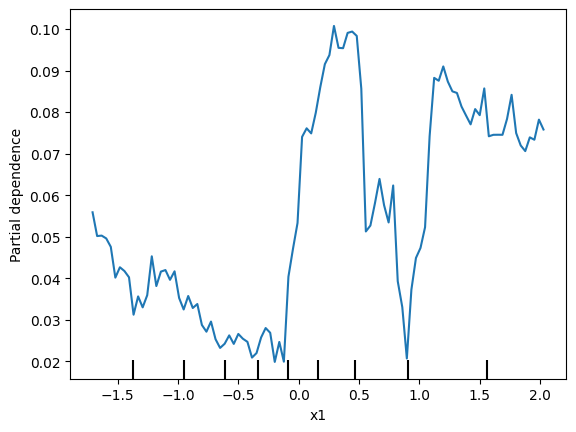

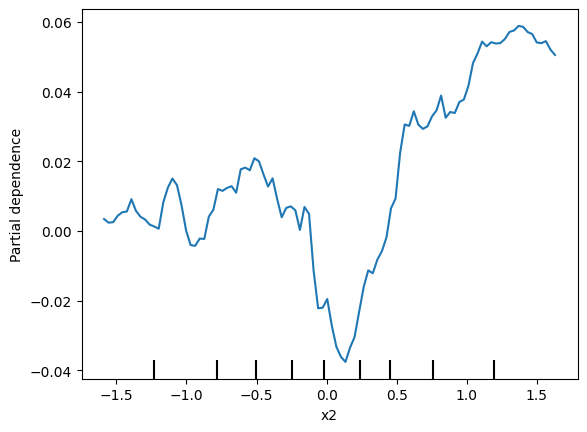

In [54]:
from sklearn.inspection import PartialDependenceDisplay

forest = test_model(f"RandomForest", RandomForestRegressor(n_estimators=200, max_depth=6, max_samples=0.4, criterion="squared_error", oob_score=False, n_jobs=-1, random_state=2611), X_lda)[0]
print(forest.feature_importances_)

PartialDependenceDisplay.from_estimator(forest, X_lda, (0,))
PartialDependenceDisplay.from_estimator(forest, X_lda, (1,))
PartialDependenceDisplay.from_estimator(forest, X_lda, (2,))

Considering the `feature_importance` values for each feature, it can be seen that `LD1` overwhelmingly defines the predicted value. It's relationship to the output is almost linear, monotonically growing. There are several notable instances where the graph plateaus and then suddenly jumps up.

The other two features have a falling and growing tendencies respectively, outside of a single large spike which seems to appear at similar positions in their range with the opposite sign. This could point to an interaction between the features. This can be better illustrated by a 2D PDP.

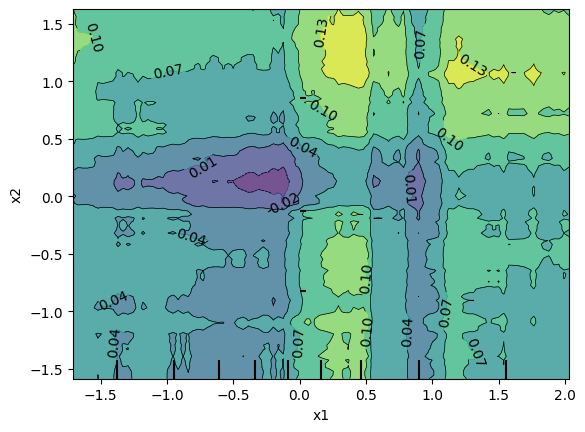

In [57]:
PartialDependenceDisplay.from_estimator(forest, X_lda, ((1, 2),))

At some point of `LD3` the behaviour of `LD2` quickly changes, growing rapidly after crossing the zero point.

For evaluation, the conclusions about `LD1` are validated. The conclusions about `LD2` being negatively correlated with crime were too simple. Both `LD2` and `LD3` have generally preferred spots where crime is the lowest, while also interacting in places to create islands of elevated crime rates. All of this is not that substantial however, considering the overwhelming feature importance of `LD1`. 

In [63]:
test_model(f"RandomForest", RandomForestRegressor(n_estimators=200, max_depth=6, max_samples=0.4, criterion="squared_error", oob_score=False, n_jobs=-1, random_state=2611), X_lda[:, [0]])
pass

RandomForest : R²: 0.7007


It appears that `LD1` can explain $70\%$ of variance by itself.

**In conclusion:** The best way to prevent violent crime is developing communities (e.g. urbanisation) and removing poverty.